# Importing Libraries and Loading Dataset

In [5]:
# Importing Libraries and Loading Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.inspection import permutation_importance

import time

# Load datasets
train_data = pd.read_csv('loan/loan-10k.lrn.csv')
test_data = pd.read_csv('loan/loan-10k.tes.csv')


# Dataset preprocessing


In [6]:
# Training Dataset
print("Training Dataset Information:")
print(train_data.info())
print("\nTraining Dataset Sample:")
print(train_data.head())

# Test Dataset
print("\nTest Dataset Information:")
print(test_data.info())
print("\nTest Dataset Sample:")
print(test_data.head())

Training Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 92 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          10000 non-null  int64  
 1   loan_amnt                   10000 non-null  float64
 2   funded_amnt                 10000 non-null  float64
 3   funded_amnt_inv             10000 non-null  float64
 4   term                        10000 non-null  object 
 5   int_rate                    10000 non-null  float64
 6   installment                 10000 non-null  float64
 7   emp_length                  10000 non-null  object 
 8   home_ownership              10000 non-null  object 
 9   annual_inc                  10000 non-null  float64
 10  verification_status         10000 non-null  object 
 11  loan_status                 10000 non-null  object 
 12  pymnt_plan                  10000 non-null  object 
 13  pu

# Vizualisation 


Selected Top Numerical Features Based on Variance:
Index(['tot_hi_cred_lim', 'tot_cur_bal', 'annual_inc', 'total_bal_ex_mort',
       'total_il_high_credit_limit', 'total_rev_hi_lim', 'total_bc_limit',
       'revol_bal', 'bc_open_to_buy', 'avg_cur_bal'],
      dtype='object')
Statistical Summary of Top Numerical Features:


,tot_hi_cred_lim,tot_cur_bal,annual_inc,total_bal_ex_mort,total_il_high_credit_limit,total_rev_hi_lim,total_bc_limit,revol_bal,bc_open_to_buy,avg_cur_bal
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,1.914525e+05,1.541102e+05,8.212897e+04,5.535178e+04,48294.371800,3.574960e+04,2.423097e+04,16977.031900,12028.534000,14118.518000
std,1.846940e+05,1.660660e+05,6.769284e+04,5.243803e+04,46981.179499,3.565504e+04,2.539548e+04,23574.688283,16664.058967,16543.350515
min,2.700000e+03,0.000000e+00,5.000000e+03,0.000000e+00,0.000000,5.000000e+02,2.000000e+02,0.000000,0.000000,0.000000
25%,5.774125e+04,3.381850e+04,5.000000e+04,2.424650e+04,18881.250000,1.540000e+04,8.800000e+03,6208.500000,1792.750000,3431.750000
50%,1.298690e+05,9.370650e+04,7.000000e+04,4.151350e+04,36533.500000,2.660000e+04,1.710000e+04,11844.000000,5982.500000,8049.500000
75%,2.752100e+05,2.279442e+05,9.700000e+04,6.880825e+04,63500.500000,4.482500e+04,3.140000e+04,20702.500000,15493.250000,19467.750000
max,2.532616e+06,2.147961e+06,3.200000e+06,1.226094e+06,768775.000000,1.090700e+06,1.090700e+06,988767.000000,213211.000000,267667.000000


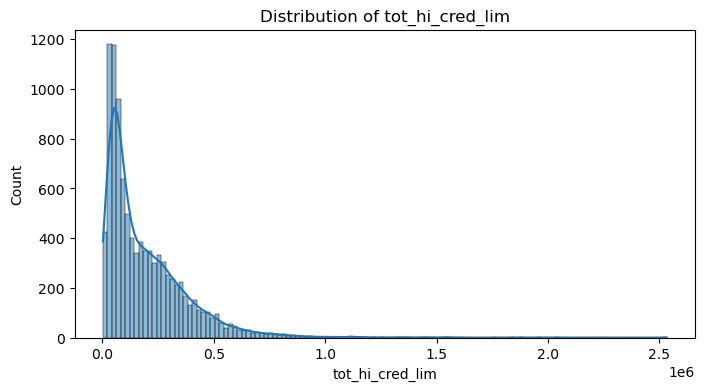

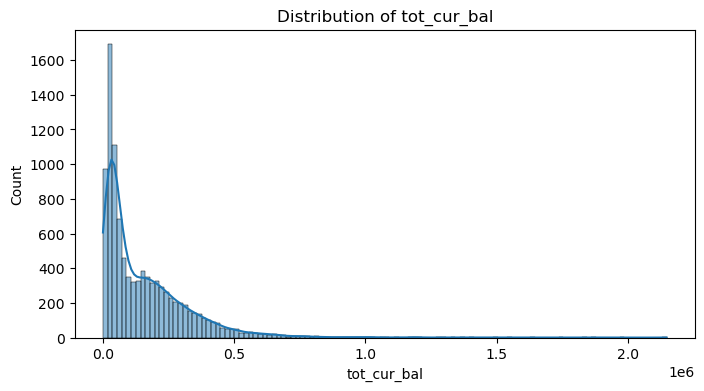

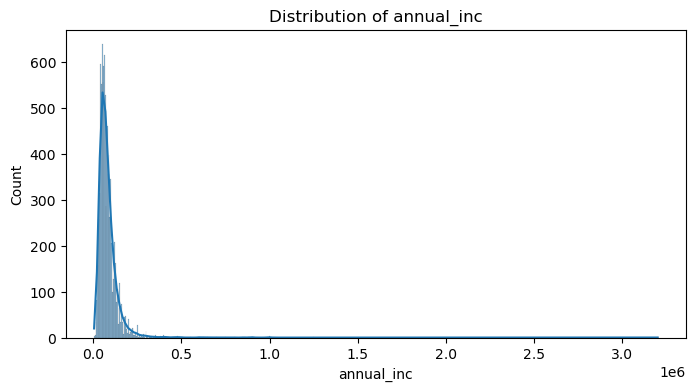

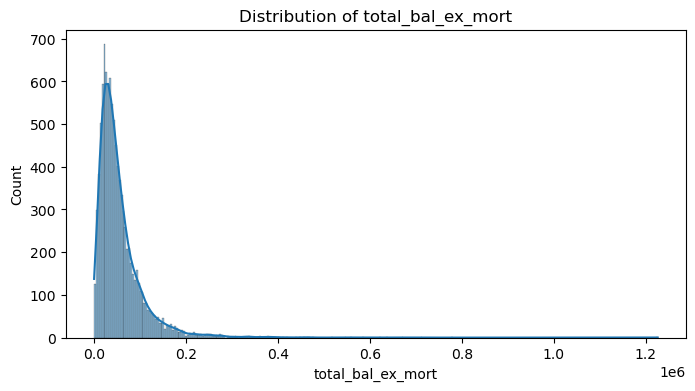

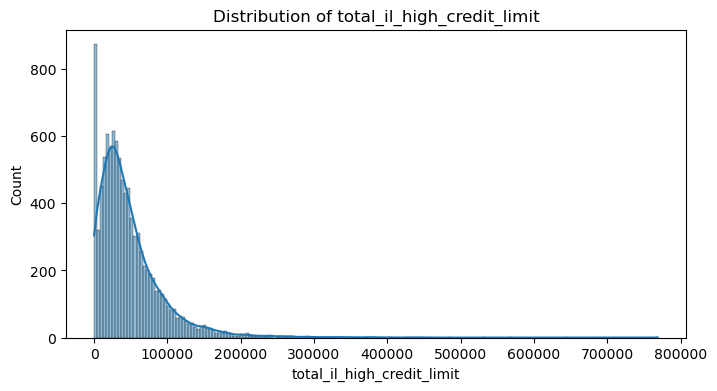

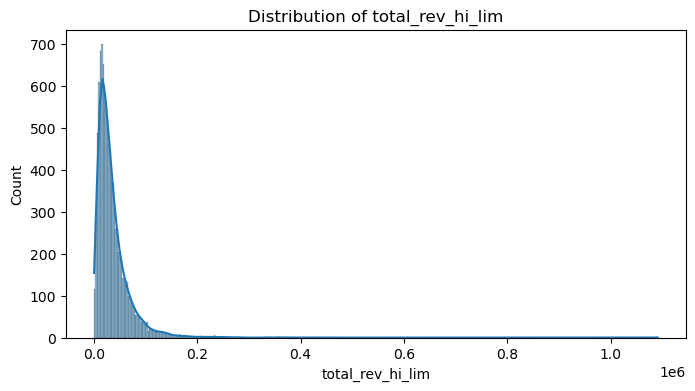

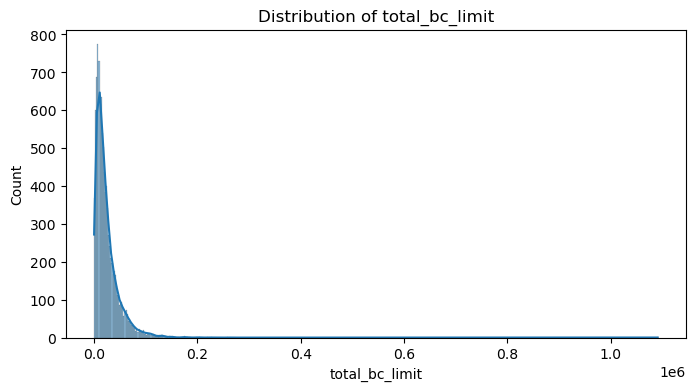

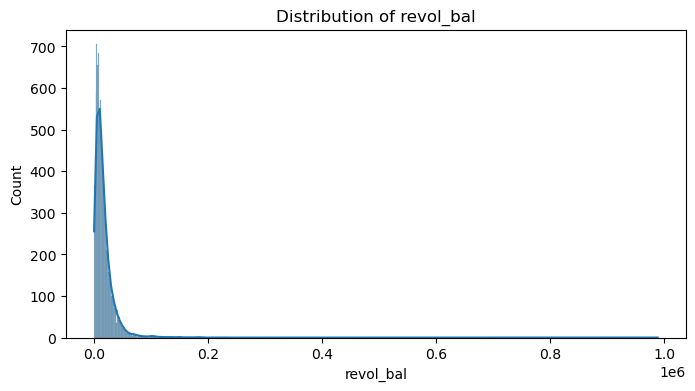

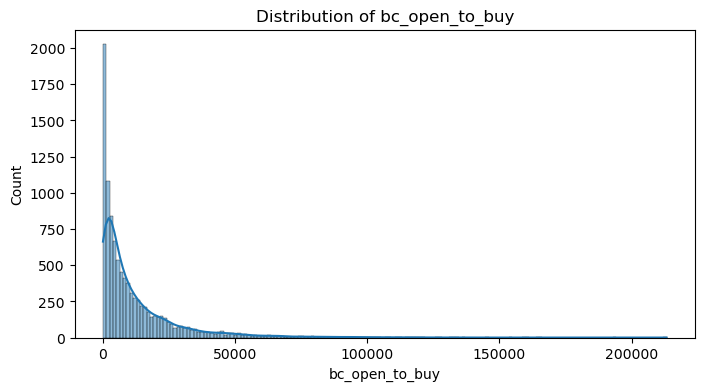

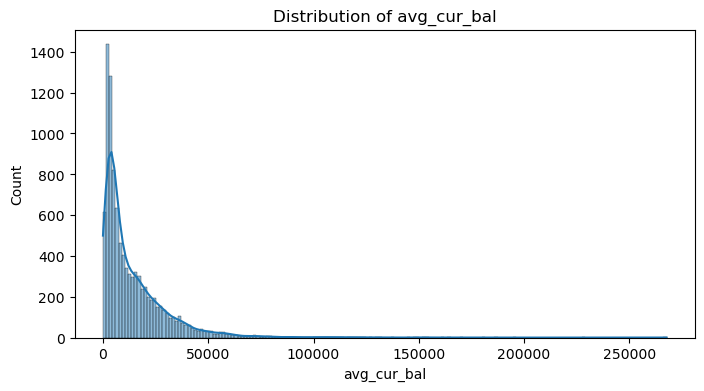

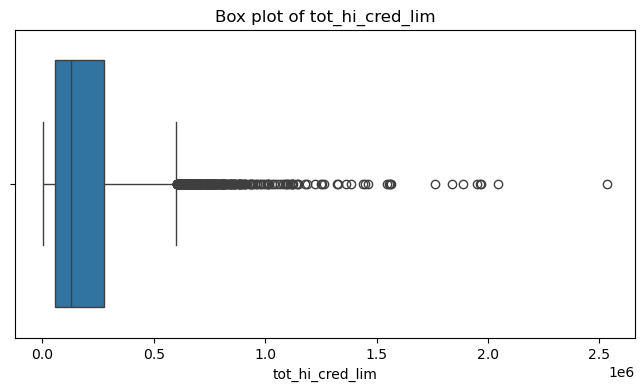

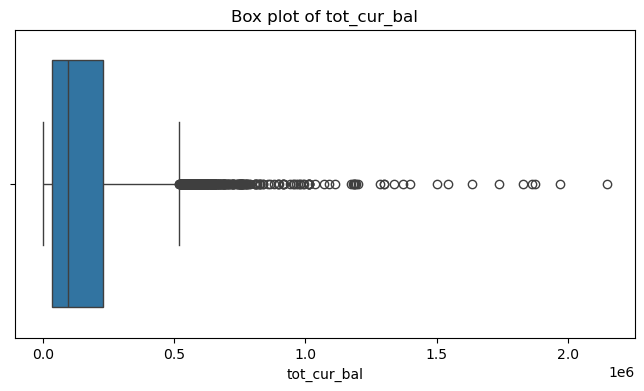

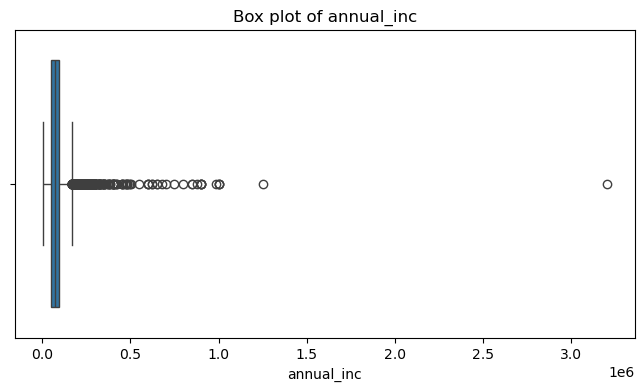

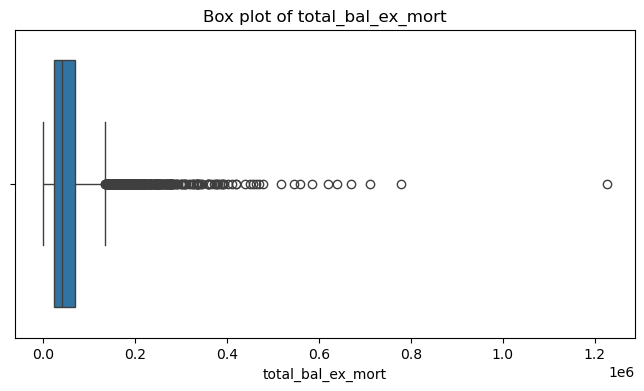

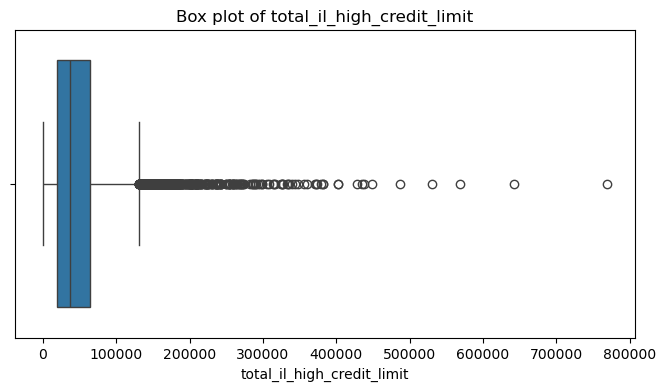

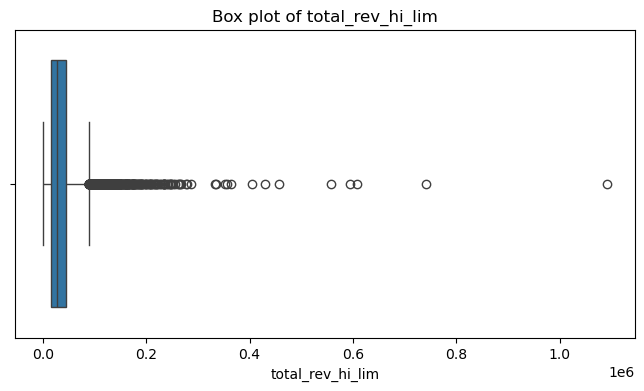

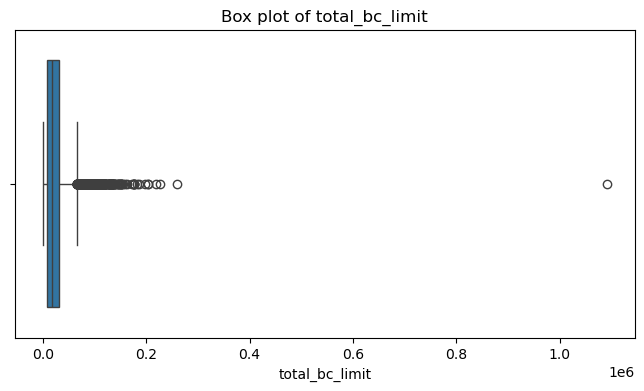

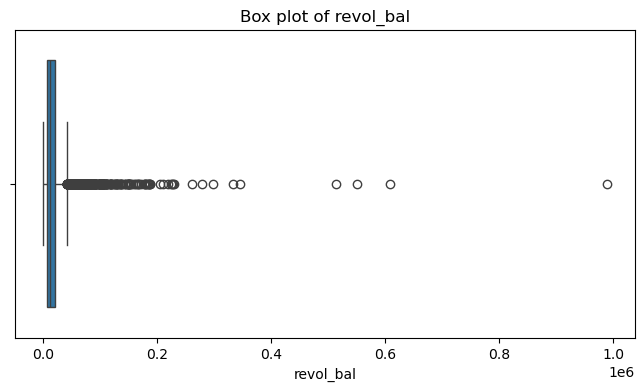

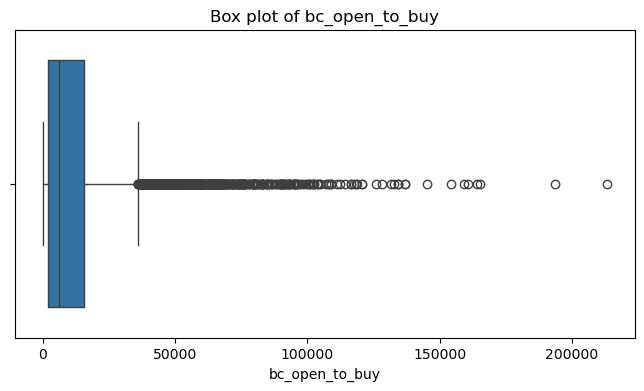

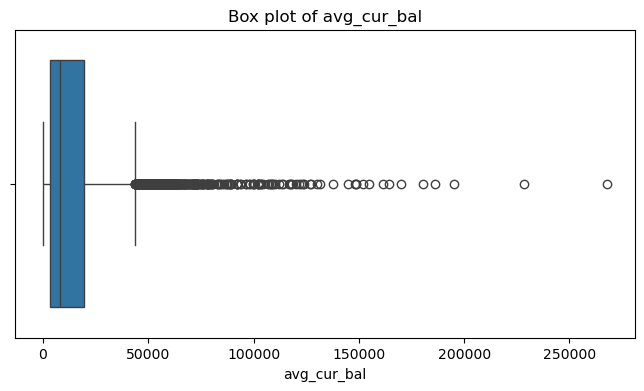

Selected Top Categorical Features Based on Unique Values:
Index(['addr_state', 'purpose', 'emp_length', 'loan_status', 'home_ownership',
       'verification_status', 'term', 'pymnt_plan', 'initial_list_status',
       'application_type'],
      dtype='object')


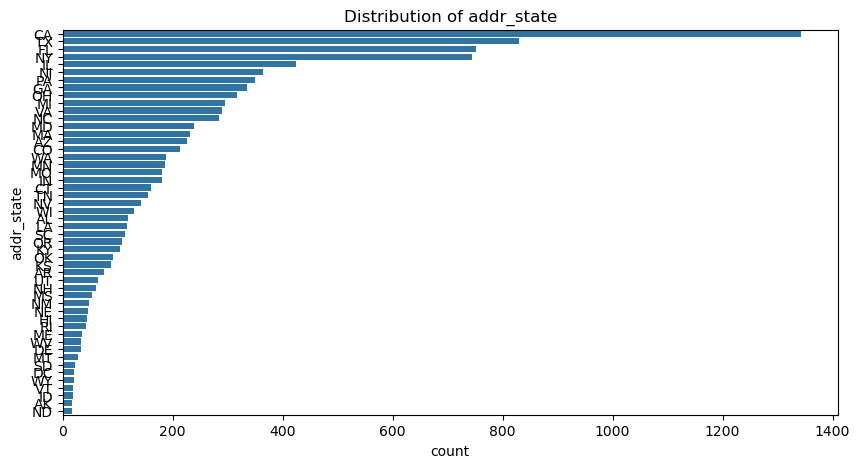

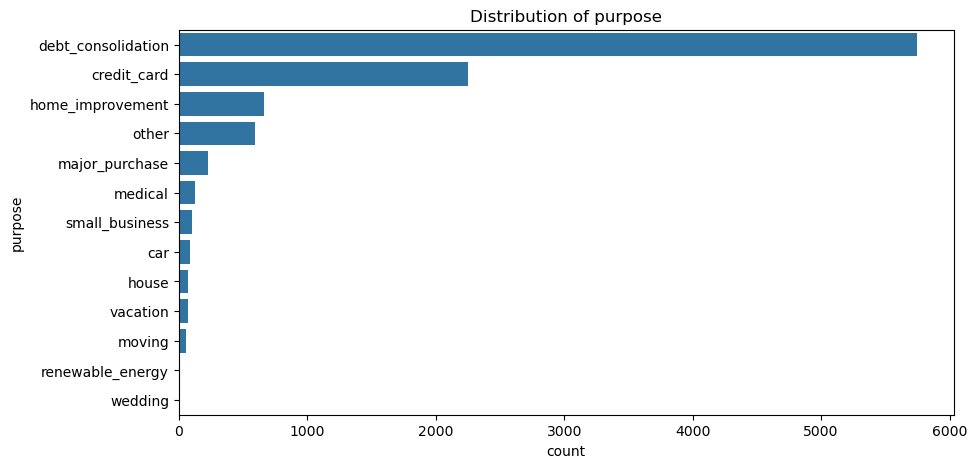

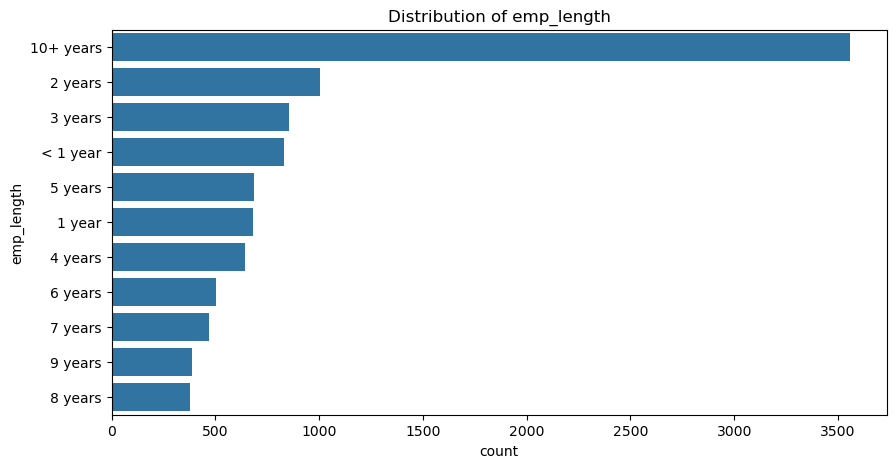

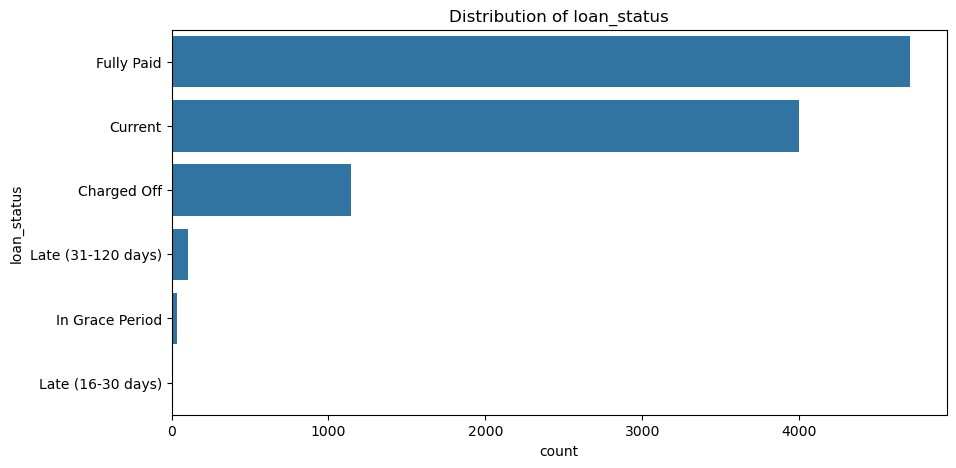

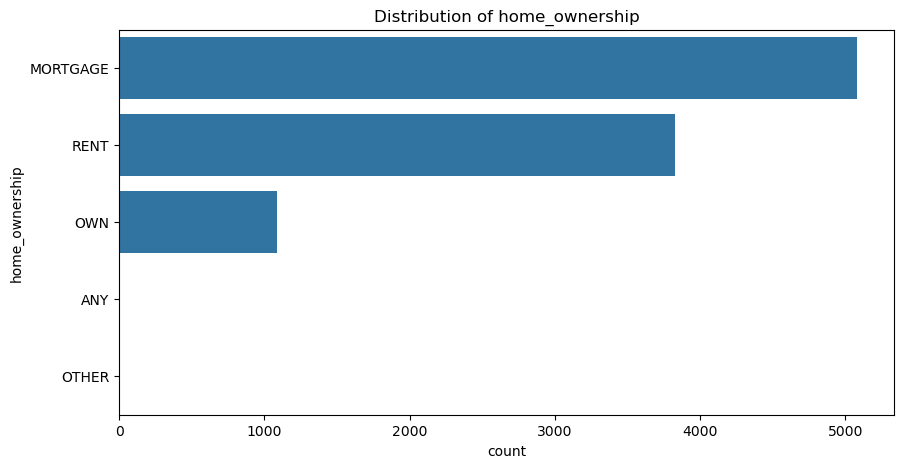

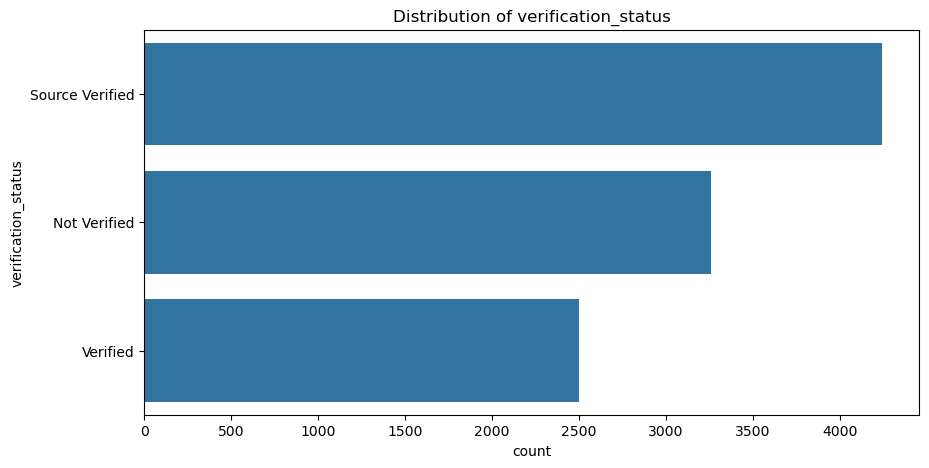

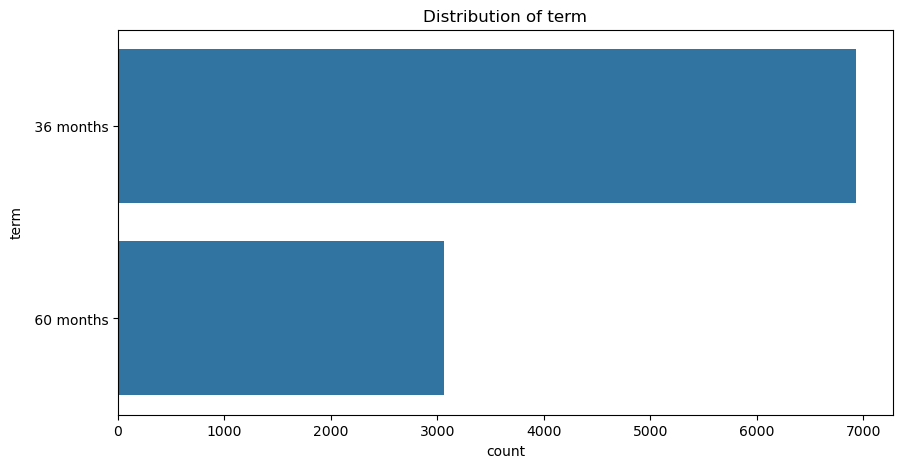

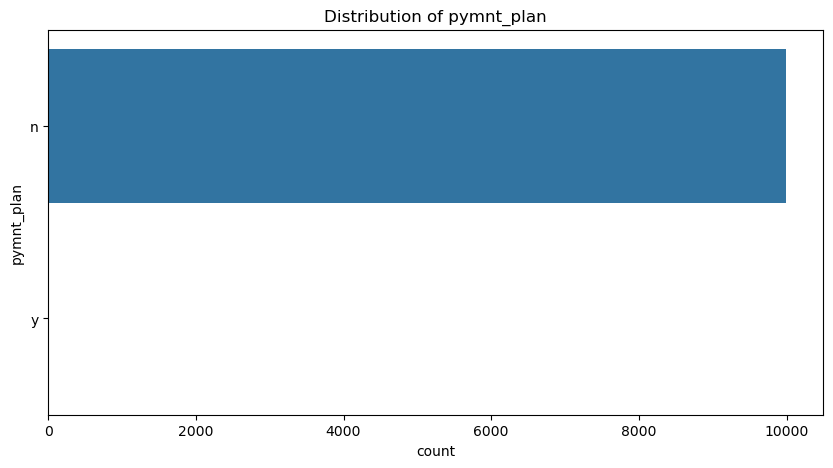

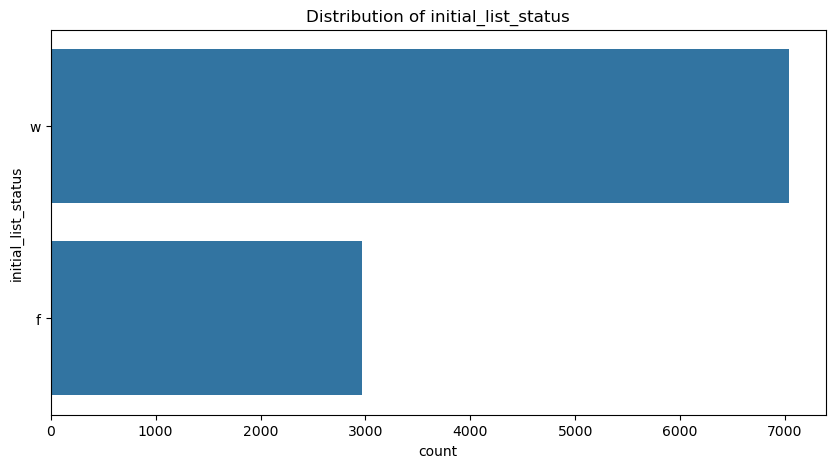

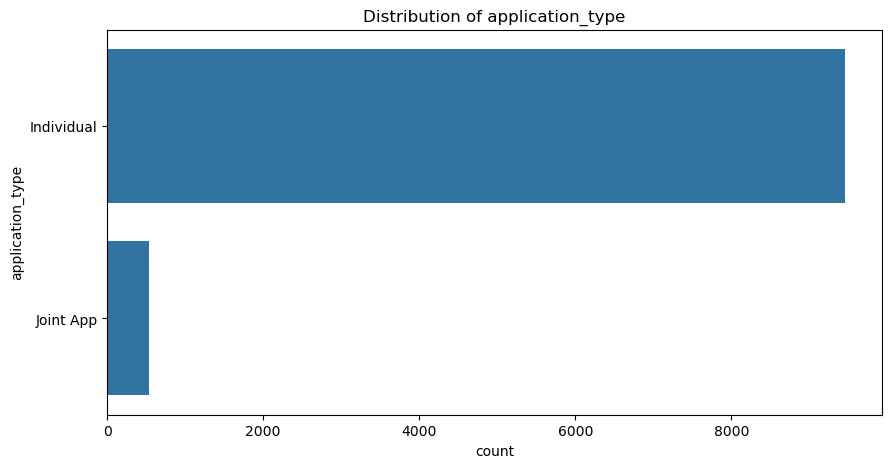

In [7]:
# Identify numeric and categorical features
numeric_features = train_data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train_data.select_dtypes(exclude=['int64', 'float64']).columns

target_col = 'grade'
if target_col in numeric_features:
    numeric_features = numeric_features.drop(target_col)
if target_col in categorical_features:
    categorical_features = categorical_features.drop(target_col)
    
numeric_features = numeric_features.drop('ID')

# Select top numerical features based on variance
variance = train_data[numeric_features].var().sort_values(ascending=False)
top_numeric_features = variance.index[:10]

print("Selected Top Numerical Features Based on Variance:")
print(top_numeric_features)

# Statistical summaries for top numerical features
print("Statistical Summary of Top Numerical Features:")
display(train_data[top_numeric_features].describe())

# Histograms/Density Plots for Top Numerical Features
for feature in top_numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(train_data[feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

# Box Plots for Top Numerical Features
for feature in top_numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=train_data[feature].dropna())
    plt.title(f'Box plot of {feature}')
    plt.show()

# Select top categorical features based on number of unique values
unique_counts = train_data[categorical_features].nunique().sort_values(ascending=False)
top_categorical_features = unique_counts.index[:10]

print("Selected Top Categorical Features Based on Unique Values:")
print(top_categorical_features)

# Analysis of Top Categorical Features
for feature in top_categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(y=train_data[feature], order=train_data[feature].value_counts().index)
    plt.title(f'Distribution of {feature}')
    plt.show()


# Data preprocessing and vizualization

In [8]:
# Handle missing columns in test data
missing_columns = set(train_data.columns) - set(test_data.columns)
if missing_columns:
    print(f"\nMissing columns in test dataset: {missing_columns}")
    for col in missing_columns:
        test_data[col] = np.nan  

# Drop extra columns in test data
extra_columns = set(test_data.columns) - set(train_data.columns)
if extra_columns:
    print(f"\nExtra columns in test dataset: {extra_columns}")
    test_data = test_data.drop(columns=extra_columns)

# Separate target variable
target_col = 'grade'
X_train = train_data.drop(columns=[target_col])
y_train = train_data[target_col]
X_test = test_data  # Assuming 'grade' is not in test_data

# Encode target variable
label_enc = LabelEncoder()
y_train_encoded = label_enc.fit_transform(y_train)

# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

# Define preprocessing steps for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])



Missing columns in test dataset: {'grade'}


In [9]:
X_test = X_test.drop('grade', axis=1)

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [11]:
X_train_split, X_eval, y_train_split, y_eval = train_test_split(X_train_processed, y_train_encoded, test_size=0.3, random_state=42)

In [12]:
y_train_split = pd.Series(y_train_split, name='target')
y_eval = pd.Series(y_eval, name='target')

In [13]:
X_train_split_df = pd.DataFrame(X_train_split)
X_eval_df = pd.DataFrame(X_eval)
X_test_processed_df = pd.DataFrame(X_test_processed)
y_train_split_df = pd.DataFrame(y_train_split)
y_eval_df = pd.DataFrame(y_eval)

In [ ]:

# save datasets
X_train_split_df.to_csv('loan_preprocessed/X_train.csv', index=False)
X_eval_df.to_csv('loan_preprocessed/X_validation.csv', index=False)
X_test_processed_df.to_csv('loan_preprocessed/X_test.csv', index=False)
y_train_split_df.to_csv('loan_preprocessed/y_train.csv', index=False)
y_eval_df.to_csv('loan_preprocessed/y_validation.csv', index=False)

In [14]:
X_train_split_df.shape

(7000, 180)